In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [5]:
df = pd.read_csv("credit_risk_200.csv")

In [6]:
X = df.drop("default", axis=1)
y = df["default"]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30 , random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
cr = classification_report(y_test, y_pred)
print(cr)

0.9166666666666666
[[49  0]
 [ 5  6]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        49
           1       1.00      0.55      0.71        11

    accuracy                           0.92        60
   macro avg       0.95      0.77      0.83        60
weighted avg       0.92      0.92      0.91        60



In [11]:
model=LogisticRegression()
penalty=['l1', 'l2']
c_values=[10,1.0,0.1,0.01]
solver=[ 'liblinear', 'saga']

In [12]:
params = dict(penalty=penalty,C=c_values,solver=solver)     

In [13]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [14]:
grid.fit(X_train,y_train)
grid.best_score_

np.float64(0.9214285714285715)

ROC-AUC: 0.9833024118738404


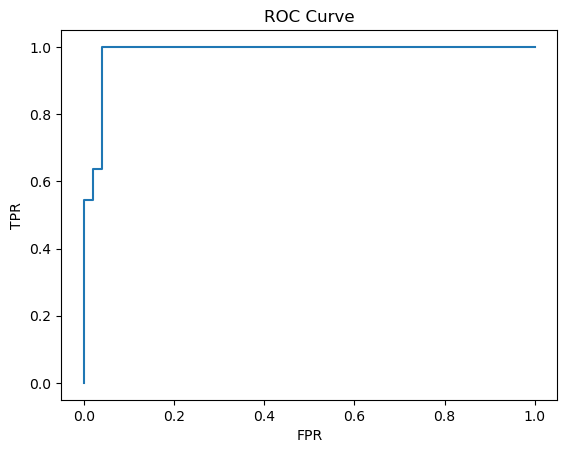

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = grid.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [16]:
import pickle
pickle.dump(grid, open("model.pkl", "wb"))

In [17]:
pickle.dump(scaler, open("scaler.pkl", "wb"))